# Sentinel-3 SLSTR Land Surface Temperature

* **Products used:** 
[s3_slstr_l2_lst](https://explorer.digitalearth.africa/products/s3_slstr_l2_lst)

## Background

The Sentinel-3 SLSTR Level-2 Land Surface Temperature (LST) product contains data derived from the Sea and Land Surface Temperature Radiometer (SLSTR) instrument. The data is available at approximately **1km resolution** with an **approximately daily revisit frequency** with both satellites combined.  making it valuable for a wide range of applications, including:

* Climate monitoring
* Urban development planning and monitoring
* Vegetation health and stress monitoring
* Evapotranspiration estimation

Further information on the Sentinel-3 SLSTR Level-2 LST product is available on [SentiWiki](https://sentiwiki.copernicus.eu/web/slstr-products#S3-SLSTR-Products-L2-LST-Products) and in the [Sentinel-3 SLSTR Land User Handbook](https://sentinels.copernicus.eu/documents/247904/4598082/Sentinel-3-SLSTR-Land-Handbook.pdf).
***

## Description

This notebook will cover following topics:

1. Inspecting the products and measurements available in the datacube
2. Loading Sentinel-3 SLSTR Data.
3. Understanding and applying the bit mask.
4. Plotting the results
5. Converting Kelvin to Celsius

***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import datacube
import geopandas as gpd
from odc.geo.geom import Geometry

from deafrica_tools.plotting import display_map
from datacube.utils import masking
from deafrica_tools.areaofinterest import define_area

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.

In [2]:
dc = datacube.Datacube(app="Sentinel_3")

### List products

We can use datacube's `list_products` functionality to inspect DE Africa's products that are available in the datacube. The table below shows the product names that we will use to load the data, a brief description of the data, and the satellite instrument that acquired the data.

In [3]:
dc.list_products().loc[dc.list_products()['description'].str.contains('Sentinel-3')]

,name,description,license,default_crs,default_resolution
name,,,,,
s3_ol_2_wfr_nrt,s3_ol_2_wfr_nrt,Sentinel-3 Level 2 Water Full Resolution (WFR)...,CC-BY-4.0,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_olci_l2_lfr,s3_olci_l2_lfr,Sentinel-3 OLCI L2 LAND,CC-BY-4.0,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_olci_l2_wfr,s3_olci_l2_wfr,Sentinel-3 OLCI L2 WATER,CC-BY-4.0,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_slstr_l2_lst,s3_slstr_l2_lst,Sentinel-3 LST,CC-BY-4.0,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_syn_2_vg1,s3_syn_2_vg1,Sentinel-3 Level-2 VG1 SYN product,CC-BY-4.0,EPSG:4326,"Resolution(x=0.01, y=-0.01)"


Please choose the product by specifying its name, with the product `s3_slstr_l2_lst`

In [4]:
product = "s3_slstr_l2_lst"

### List measurements

We can further inspect the data available for the Sentinel-3 Land `s3_slstr_l2_lst` product using datacube's `list_measurements` functionality. The table below lists each of the measurements available in the data.

In [5]:
measurements = dc.list_measurements()
measurements.loc[product]

,name,dtype,units,nodata,aliases,flags_definition,add_offset,scale_factor
measurement,,,,,,,,
LST,LST,uint16,K,65535.0,[Land_surface_temperature],NaN,0.0,0.0100
LST_uncertainty,LST_uncertainty,uint16,K,65535.0,[Land_surface_temperature_uncertainty],NaN,0.0,0.0100
NDVI,NDVI,int16,1,32767.0,NaN,NaN,0.0,0.0001
CONFIDENCE,CONFIDENCE,uint16,1,65535.0,[mask],"{'day': {'bits': 10, 'values': {'0': False, '1...",NaN,NaN


The Sentinel-3 Land product has four measurements:

| Measurement                                   | Description                                                                                                                             | Application                                                                                      |
| --------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------ |
| **LST** (Land Surface Temperature)       | Land Surface Temperature expressed in degrees Kelvin. | Numerous applications across climate monitoring, land cover and land use assessments, change detection, and biophysical modelling. |
| **LST_uncertainty** (Land Surface Temperature Uncertainty)   | The total standard uncertainty of the the LST measure, expressed in Kelvin.         | Quality control and support for downstream uncertainty estimation in modelling workflows.                     |
| **NDVI** (Normalised Difference Vegetation Index) | Unitless measure of vegetation greenness and density.     | Crop stress detection, canopy functioning studies, biomass dynamics monitoring.               
| **CONFIDENCE**                                  | Bit mask layer flagging various pixel conditions such as cloud and sun glint.   |Quality control and masking.|

***

### Analysis parameters

The following cell sets the parameters, which define the area of interest to conduct the analysis over.
#### Select location
To define the area of interest, there are two methods available:

1. By specifying the latitude, longitude, and buffer, or separate latitude and longitude buffers, this method allows you to define an area of interest around a central point. You can input the central latitude, central longitude, and a buffer value in degrees to create a square area around the center point. For example, `lat = 10.338`, `lon = -1.055`, and `buffer = 0.1` will select an area with a radius of 0.1 square degrees around the point with coordinates `(10.338, -1.055)`. 
    
    Alternatively, you can provide separate buffer values for latitude and longitude for a rectangular area. For example, `lat = 10.338`, `lon = -1.055`, and `lat_buffer = 0.1` and`lon_buffer = 0.08` will select a rectangular area extending 0.1 degrees north and south, and 0.08 degrees east and west from the point `(10.338, -1.055)`.

   For reasonable loading times, set the buffer as `0.1` or lower.

3. By uploading a polygon as a `GeoJSON or Esri Shapefile`. If you choose this option, you will need to upload the geojson or ESRI shapefile into the Sandbox using Upload Files button <img align="top" src="../Supplementary_data/upload_files_icon.png"> in the top left corner of the Jupyter Notebook interface. ESRI shapefiles must be uploaded with all the related files `(.cpg, .dbf, .shp, .shx)`. Once uploaded, you can use the shapefile or geojson to define the area of interest. Remember to update the code to call the file you have uploaded.

To use one of these methods, you can uncomment the relevant line of code and comment out the other one. To comment out a line, add the `"#"` symbol before the code you want to comment out. By default, the first option which defines the location using latitude, longitude, and buffer is being used.

**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.
The example covers the Zambezi River Delta in Mozambique. This area includes land and ocean to demonstrate ocean masking, and also experiences some cloud cover. There is some topographical variation in the area of interest with can produce land surface temperature variability.

**To run the notebook for a different area**, make sure Sentinel-3 OLCI Land data is available for the chosen area using the [DEAfrica Explorer](https://explorer.digitalearth.africa).

In [6]:
# Method 1: Specify the latitude, longitude, and buffer)
aoi = define_area(lat=-18.7, lon=36.4, buffer=0.9)

# Method 2: Use a polygon as a GeoJSON or Esri Shapefile. 
# aoi = define_area(vector_path='aoi.shp')

#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

In [7]:
display_map(x=lon_range, y=lat_range)

## Load Sentinel-3 dataset using `dc.load()`

Now that we know what products and measurements are available for the product, we can load data from the datacube using `dc.load`. We will load data from spectral satellite bands. By specifying `output_crs='EPSG:4326'` and `resolution=(-0.01, 0.01`), we are querying the data in degrees with approximately 1km x 1km pixels, **noting that `EPSG:4326` is not an equal area projection**. Finally, `group_by='solar_day'` ensures that overlapping images taken within seconds of each other as the satellite passes over are combined into a single time step in the data. We can see that the query returns eight time steps as we have queried the first fifteen days of April 2025.

In [8]:
query = {
    'x': (lon_range),
    'y': (lat_range),
    'time':('2025-04-01', '2025-04-15'),
    'output_crs': 'EPSG:4326',
    'resolution': (-0.01, 0.01)}

ds_S3 = dc.load(product=product,
                group_by="solar_day",
                **query)

ds_S3

<xarray.Dataset> Size: 4MB
Dimensions:          (time: 15, latitude: 180, longitude: 180)
Coordinates:
  * time             (time) datetime64[ns] 120B 2025-04-01T09:45:41.204500 .....
  * latitude         (latitude) float64 1kB -17.8 -17.82 ... -19.59 -19.59
  * longitude        (longitude) float64 1kB 35.51 35.52 35.53 ... 37.29 37.3
    spatial_ref      int32 4B 4326
Data variables:
    LST              (time, latitude, longitude) uint16 972kB 29764 ... 65535
    LST_uncertainty  (time, latitude, longitude) uint16 972kB 45 45 ... 65535
    NDVI             (time, latitude, longitude) int16 972kB 32767 ... 32767
    CONFIDENCE       (time, latitude, longitude) uint16 972kB 8 8 264 ... 258 2
Attributes:
    crs:           EPSG:4326
    grid_mapping:  spatial_ref

> **⚠️ Note:**  Some Sentinel-3 SLSTR Land bands are stored as integers with a scale factor **(e.g., 0.01) or offset (e.g., 100)** applied. This scaling is used to efficiently store values in integer format. To obtain the correct surface values, the scale or offset must be applied. The cells below demonstrate how this is applied to temperature measurements using the scale factor of 0.01 (visible when the metadata is expanded in the dataset above).

As a next step, we store a `scale_factor` object for use in later plots and calculations. The scale factor is extracted from the attributes of the LST variable. We would have to get the specific scale factor for the uncertainty or NDVI variables if we were working with them.

In [9]:
scale_factor_LST = ds_S3['LST'].attrs.get('scale_factor')
scale_factor_LST_unc = ds_S3['LST_uncertainty'].attrs.get('scale_factor')

## Understanding the Confidence layer and bitmasking

The Sentinel-3 LST data is only available over land (not ocean) and is sensitive to cloud and other interference. In the `xarray` object `ds_S3` above, we can see several 65535 values in the LST variable which represent `nodata`. We need to effectively mask the dataset before proceeding.

The `CONFIDENCE` layer uses a bitmask to encode pixel-level flags, such as cloud presence or sun glint, into a single integer. Bitmask refers to binary digits, where the position of the digit in a series relates to a particular flag. In the `CONFIDENCE` layer, flags are marked true or false with 1s and 0s at specific locations in an integer. Looking at the table below, a 1 at bit location 1 (noting 0 indexing and reading left-to-right, this would be `-1-------...`) would indicate the pixel is over ocean, while a 0 at bit location 3 (`---0-----...`) would indicate the pixel _is not_ over land.

Each active flag contributes a value of $2^{\text{position}}$ to the total integer. For example, if a pixel was over land (position 3, value $2^3=8$), had cosmetic defects (position 8, value $2^8=256$), and was cloudy (position 14, value $2^{14}=16384$), the resulting integer would be:

$$
2^3 + 2^8 + 2^{14} = 16648
$$

Looking at the `CONFIDENCE` band in the `ds_S3` object above, there are a few 16648 values. We have to work backwards from this value to find the unique combination of bit positions with raised flags. Fortunately, computers do this easily and we can draw on the datacube `masking` functions to assist.

The table below shows the bits in the Sentinel-3 LST product.

In [10]:
# Display details of available flags
flags = masking.describe_variable_flags(ds_S3.CONFIDENCE)
flags

,bits,values,description
day,10,"{'0': False, '1': True}",Day
land,3,"{'0': False, '1': True}",Land
snow,13,"{'0': False, '1': True}",Snow
ocean,1,"{'0': False, '1': True}",Ocean
tidal,2,"{'0': False, '1': True}",Tidal
cosmetic,8,"{'0': False, '1': True}",Cosmetic defect
twilight,11,"{'0': False, '1': True}",Twilight
unfilled,5,"{'0': False, '1': True}",Unfilled
coastline,0,"{'0': False, '1': True}",Coastline
duplicate,9,"{'0': False, '1': True}",Duplicate


### Apply the mask

Next, we list the flags we want to mask in a dictionary and apply the `make_mask` function before implementing it on our dataset. In this case, we've chosen three flags: cloud, ocean, unfilled. You can experiement with adding and removing other flags.

In [11]:
clear = {"summary_cloud": False, "ocean": False, "unfilled": False}

mask = masking.make_mask(ds_S3.CONFIDENCE, **clear)

ds_S3_masked = ds_S3.where(mask == True)

## Plot LST and uncertainty in Kelvin

Now that we've applied the mask, we can plot LST and its associated uncertainty, both expressed in Kelvin. Importantly, we apply the scale factor in the plotting commands.

Surface temperatures appear higher along the coasts and in the low lying parts of the Delta, and cooler in the higher topography in the north-west of the area of interest. This is most evident in the 2nd and 14th of April images.

We can also see that the uncertainty values range between 0 and 5 Kelvin. Interestingly, uncertainty appears higher over surface water (the Zambezi River), especially for the 2nd and 5th of April images.

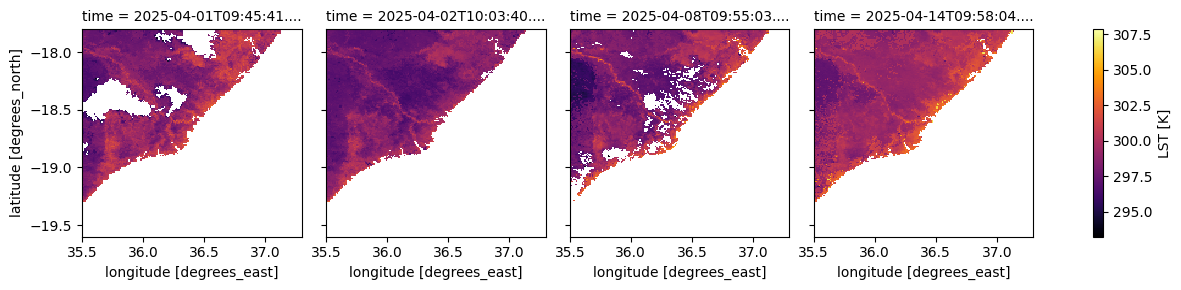

In [12]:
(ds_S3_masked.isel(time=[0,1,7,13]).LST*scale_factor_LST).plot(col='time', cmap = 'inferno')

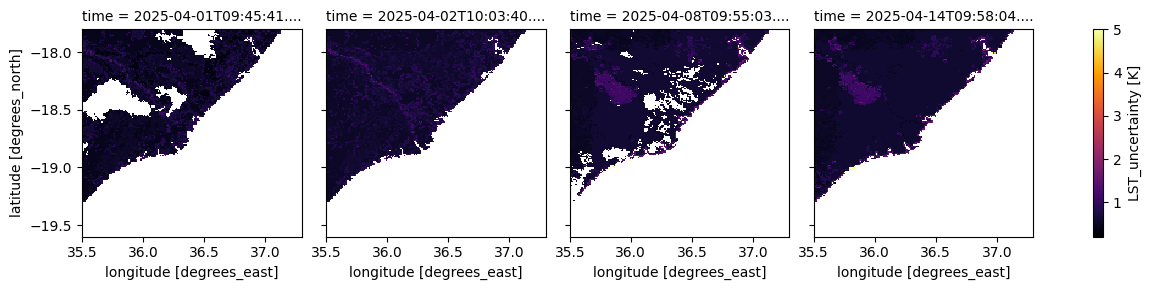

In [13]:
(ds_S3_masked.isel(time=[0,1,7,13]).LST_uncertainty*scale_factor_LST_unc).plot(col='time', cmap = 'inferno')

### Convert LST to Celsius

We can convert Kelvin to Celsius by subtracting 273.15 and plot the result. Using Celsius may be more relatable for some audiences, noting that LST in the area and period plotted ranges between around 20 and 33 degrees Celsius, with cooler temperatures seen in the 5th April image.

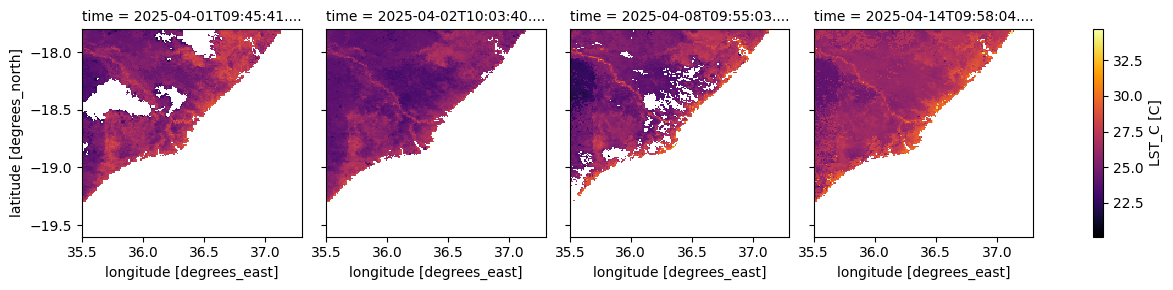

In [14]:
# convert K to C and assign units as an attribute
ds_S3_masked['LST_C'] = (ds_S3_masked.LST*scale_factor_LST - 273.15).assign_attrs(units = "C")

(ds_S3_masked.isel(time=[0,1,7,13]).LST_C).plot(col='time', cmap = 'inferno')

# Conclusion and next steps

This notebook has provided an introduction into loading, masking, and plotting land surface temperature (and the uncertainty of its measurement) using bitmasking principles and applying scale factors. It might be interesting to explore different landscapes, topographies and seasons.

---

## Additional information

<b> License </b> The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

<b> Contact </b> If you need assistance, please post a question on the [DE Africa Slack channel](https://digitalearthafrica.slack.com/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).

If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

<b> Compatible datacube version </b>

In [15]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [16]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-08-18'